# Grad-CAM: Porównanie ResNet bez trenowania vs po fine-tuningu na BUSI

## Cel

Dla **tego samego obrazu** z datasetu BUSI porównujemy mapy Grad-CAM generowane przez:
- **Model A** — ResNet50 pretrenowany na ImageNet (bez żadnego trenowania na BUSI)
- **Model B** — ResNet18 po szybkim fine-tuningu klasyfikatora (3 klasy BUSI: benign / malignant / normal)

Cel: zobaczyć jak wiedza o zadaniu (klasyfikacja raka piersi) zmienia obszary na których model skupia uwagę.

## 1. Import bibliotek

In [1]:
import os
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision.models import resnet50, ResNet50_Weights

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cu130
CUDA: True


## 2. Konfiguracja

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = ['benign', 'malignant', 'normal']  # kolejność z ImageFolder
NUM_CLASSES   = 3
SEED          = 42

# Ścieżka do checkpointu z fine-tuningu (opcja C)
CHECKPOINT_PATH = 'checkpoints/resnet18_quick_busi_best.pth'

OUTPUT_DIR = 'gradcam_outputs/comparison'
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Device: {DEVICE}")
print(f"Checkpoint: {CHECKPOINT_PATH}")

Device: cuda
Checkpoint: checkpoints/resnet18_quick_busi_best.pth


## 3. Wykrywanie datasetu i wybór obrazu

Automatyczne wykrywanie folderu BUSI. Następnie losowy wybór **jednego obrazu** z każdej klasy — tego samego użyjemy dla obu modeli.

In [3]:
def find_dataset_root():
    base = Path('.')
    for candidate in [base / 'Dataset_BUSI_noisy', base / 'Dataset_BUSI_with_GT']:
        if candidate.exists():
            subdirs = {d.name for d in candidate.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return candidate
    for folder in base.rglob('*'):
        if folder.is_dir():
            subdirs = {d.name for d in folder.iterdir() if d.is_dir()}
            if {'benign', 'malignant', 'normal'}.issubset(subdirs):
                return folder
    raise FileNotFoundError("Nie znaleziono folderu BUSI z podfolderami: benign/, malignant/, normal/")


def pick_sample_per_class(dataset_root, classes, seed=SEED):
    """Zwraca słownik {klasa: Path} z jednym oryginalnym obrazem na klasę."""
    rng = random.Random(seed)
    samples = {}
    exts = {'.png', '.jpg', '.jpeg', '.bmp'}
    for cls in classes:
        cls_dir = dataset_root / cls
        images = sorted([
            p for p in cls_dir.iterdir()
            if p.suffix.lower() in exts
            and '_mask' not in p.stem
            and '__noise_' not in p.stem
        ])
        if not images:
            # fallback – weź wszystkie bez masek
            images = sorted([p for p in cls_dir.iterdir()
                             if p.suffix.lower() in exts and '_mask' not in p.stem])
        samples[cls] = rng.choice(images)
    return samples


DATASET_ROOT = find_dataset_root()
print(f"Dataset: {DATASET_ROOT.resolve()}")

selected = pick_sample_per_class(DATASET_ROOT, CLASS_NAMES)
print("\nWybrane obrazy do porównania:")
for cls, path in selected.items():
    print(f"  {cls:12s}: {path.name}")

Dataset: /home/o0i3z3/university/dl/p2/neural_networks_project/Dataset_BUSI_noisy

Wybrane obrazy do porównania:
  benign      : benign (124).png
  malignant   : malignant (104).png
  normal      : normal (42).png


## 4. Funkcje pomocnicze

In [4]:
def load_image(img_path, img_size=IMG_SIZE):
    """
    Wczytuje obraz i zwraca:
      - input_tensor: [1, 3, H, W] znormalizowany tensor dla modelu
      - rgb_img:      [H, W, 3] float32 w zakresie [0,1] do wizualizacji
    """
    img = Image.open(img_path).convert('RGB')

    preprocess = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    input_tensor = preprocess(img).unsqueeze(0)

    vis_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    rgb_img = vis_transform(img).permute(1, 2, 0).numpy().astype(np.float32)

    return input_tensor, rgb_img


def compute_gradcam(model, target_layers, input_tensor, target_class=None):
    """
    Oblicza mapę Grad-CAM.
    Tymczasowo włącza gradienty dla wszystkich parametrów
    (potrzebne gdy backbone jest zamrożony – jak w modelu B).
    """
    saved = {n: p.requires_grad for n, p in model.named_parameters()}
    for p in model.parameters():
        p.requires_grad_(True)
    try:
        targets = [ClassifierOutputTarget(target_class)] if target_class is not None else None
        with GradCAM(model=model, target_layers=target_layers) as cam:
            gray = cam(input_tensor=input_tensor, targets=targets)
        return gray[0]   # [H, W]
    finally:
        for n, p in model.named_parameters():
            p.requires_grad_(saved[n])

## 5. Model A — ResNet50 pretrenowany na ImageNet (bez trenowania na BUSI)

Model nie zna klas BUSI. Predykcja bazuje na 1000 klasach ImageNet, Grad-CAM pokazuje co sieć „nauczyła się" widzieć dla ogólnych kategorii wizualnych.

In [5]:
# Wczytanie pretrenowanego ResNet50 (ImageNet)
model_A = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model_A = model_A.to(DEVICE)
model_A.eval()

target_layers_A = [model_A.layer4[-1]]
imagenet_categories = ResNet50_Weights.IMAGENET1K_V2.meta['categories']

print(f"Model A: ResNet50 — IMAGENET1K_V2")
print(f"Liczba klas: {len(imagenet_categories)}")
print(f"Target layer: model_A.layer4[-1]")

Model A: ResNet50 — IMAGENET1K_V2
Liczba klas: 1000
Target layer: model_A.layer4[-1]


## 6. Model B — ResNet18 po fine-tuningu na BUSI

Model pochodzi z checkpointu wytrenowanego w `gradcam_option_C_quick_finetune.ipynb`. Backbone zamrożony; tylko ostatnia warstwa (FC) dotrenowana na 3 klasach BUSI.

In [6]:
ckpt_path = Path(CHECKPOINT_PATH)
if not ckpt_path.exists():
    raise FileNotFoundError(
        f"Checkpoint nie znaleziony: {ckpt_path}\n"
        "Uruchom najpierw gradcam_option_C_quick_finetune.ipynb, "
        "aby wytrenować model i zapisać checkpoint."
    )

checkpoint = torch.load(ckpt_path, map_location=DEVICE)

# Odtwórz architekturę
ckpt_model_name = checkpoint.get('model_name', 'resnet18')
if ckpt_model_name == 'resnet18':
    model_B = models.resnet18(weights=None)
elif ckpt_model_name == 'resnet50':
    model_B = models.resnet50(weights=None)
else:
    raise ValueError(f"Nieznana architektura w checkpoincie: {ckpt_model_name}")

# Zamrożony backbone + nowa warstwa FC
for param in model_B.parameters():
    param.requires_grad = False
n_classes = checkpoint.get('num_classes', NUM_CLASSES)
model_B.fc = nn.Linear(model_B.fc.in_features, n_classes)

model_B.load_state_dict(checkpoint['model_state_dict'])
model_B = model_B.to(DEVICE)
model_B.eval()

target_layers_B = [model_B.layer4[-1]]

idx_to_class_B = checkpoint.get('idx_to_class', {i: c for i, c in enumerate(CLASS_NAMES)})
# Konwersja kluczy do int (mogą być stringami po serializacji JSON)
idx_to_class_B = {int(k): v for k, v in idx_to_class_B.items()}

print(f"Model B: {ckpt_model_name} — fine-tuned BUSI")
print(f"Klasy: {idx_to_class_B}")
print(f"Najlepsza dokładność val: {checkpoint.get('best_val_acc', 'N/A')}")
print(f"Epoka: {checkpoint.get('epoch', 'N/A')}")
print(f"Target layer: model_B.layer4[-1]")

Model B: resnet18 — fine-tuned BUSI
Klasy: {0: 'benign', 1: 'malignant', 2: 'normal'}
Najlepsza dokładność val: 0.7152777777777778
Epoka: 19
Target layer: model_B.layer4[-1]


## 7. Generowanie Grad-CAM i porównanie

Dla każdego wybranego obrazu tworzymy panel z 5 kolumnami:

| Obraz | Grad-CAM A | Overlay A | Grad-CAM B | Overlay B |
|-------|-----------|-----------|-----------|-----------|
| oryginał | heatmapa modelu ImageNet | nałożenie A | heatmapa modelu BUSI | nałożenie B |

In [7]:
def compare_gradcam_single(img_path, true_class, save_path=None):
    """
    Tworzy panel porównawczy Grad-CAM dla jednego obrazu:
      Kolumna 0: oryginalny obraz
      Kolumna 1: heatmapa Model A (pretrained ImageNet)
      Kolumna 2: overlay Model A
      Kolumna 3: heatmapa Model B (fine-tuned BUSI)
      Kolumna 4: overlay Model B
    """
    input_tensor, rgb_img = load_image(img_path)
    input_tensor = input_tensor.to(DEVICE)

    # --- Model A: predykcja ImageNet ---
    with torch.no_grad():
        out_A = model_A(input_tensor)
        probs_A = torch.softmax(out_A[0], dim=0)
        pred_idx_A = probs_A.argmax().item()
        pred_prob_A = probs_A[pred_idx_A].item()
        pred_label_A = imagenet_categories[pred_idx_A]

    cam_A = compute_gradcam(model_A, target_layers_A, input_tensor, target_class=pred_idx_A)
    overlay_A = show_cam_on_image(rgb_img, cam_A, use_rgb=True)

    # --- Model B: predykcja BUSI ---
    with torch.no_grad():
        out_B = model_B(input_tensor)
        probs_B = torch.softmax(out_B[0], dim=0)
        pred_idx_B = probs_B.argmax().item()
        pred_prob_B = probs_B[pred_idx_B].item()
        pred_label_B = idx_to_class_B[pred_idx_B]

    cam_B = compute_gradcam(model_B, target_layers_B, input_tensor, target_class=pred_idx_B)
    overlay_B = show_cam_on_image(rgb_img, cam_B, use_rgb=True)

    # --- Wizualizacja ---
    fig, axes = plt.subplots(1, 5, figsize=(22, 4))

    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Obraz\n(klasa BUSI: {true_class})", fontsize=10, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cam_A, cmap='jet')
    axes[1].set_title(
        f"Heatmapa — Model A\n(ImageNet: {pred_label_A[:25]}…\n{pred_prob_A:.1%})",
        fontsize=9
    )
    axes[1].axis('off')

    axes[2].imshow(overlay_A)
    axes[2].set_title("Overlay — Model A\n(pretrained ImageNet)", fontsize=9)
    axes[2].axis('off')

    axes[3].imshow(cam_B, cmap='jet')
    correct_marker = "✓" if pred_label_B == true_class else "✗"
    axes[3].set_title(
        f"Heatmapa — Model B\n(BUSI pred: {pred_label_B} {correct_marker}\n{pred_prob_B:.1%})",
        fontsize=9
    )
    axes[3].axis('off')

    axes[4].imshow(overlay_B)
    axes[4].set_title("Overlay — Model B\n(fine-tuned BUSI)", fontsize=9)
    axes[4].axis('off')

    fig.suptitle(
        f"Grad-CAM: pretrained ImageNet  vs  fine-tuned BUSI   |   plik: {Path(img_path).name}",
        fontsize=11, fontweight='bold', y=1.02
    )
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Zapisano: {save_path}")

    plt.show()
    plt.close()

    return {
        'image': Path(img_path).name,
        'true_class': true_class,
        'model_A_pred': pred_label_A,
        'model_A_prob': pred_prob_A,
        'model_B_pred': pred_label_B,
        'model_B_prob': pred_prob_B,
        'model_B_correct': pred_label_B == true_class,
    }


print("Funkcja compare_gradcam_single zdefiniowana.")

Funkcja compare_gradcam_single zdefiniowana.



Klasa: BENIGN | Obraz: benign (124).png
  Zapisano: gradcam_outputs/comparison/comparison_benign_benign (124).png


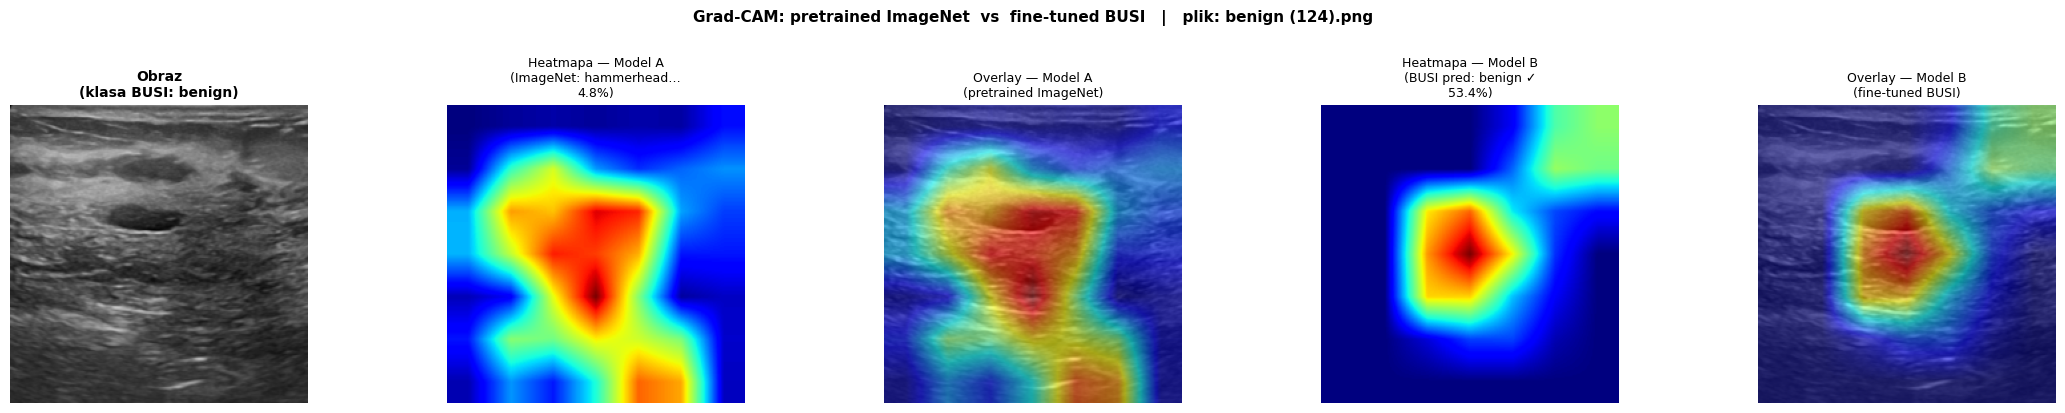


Klasa: MALIGNANT | Obraz: malignant (104).png
  Zapisano: gradcam_outputs/comparison/comparison_malignant_malignant (104).png


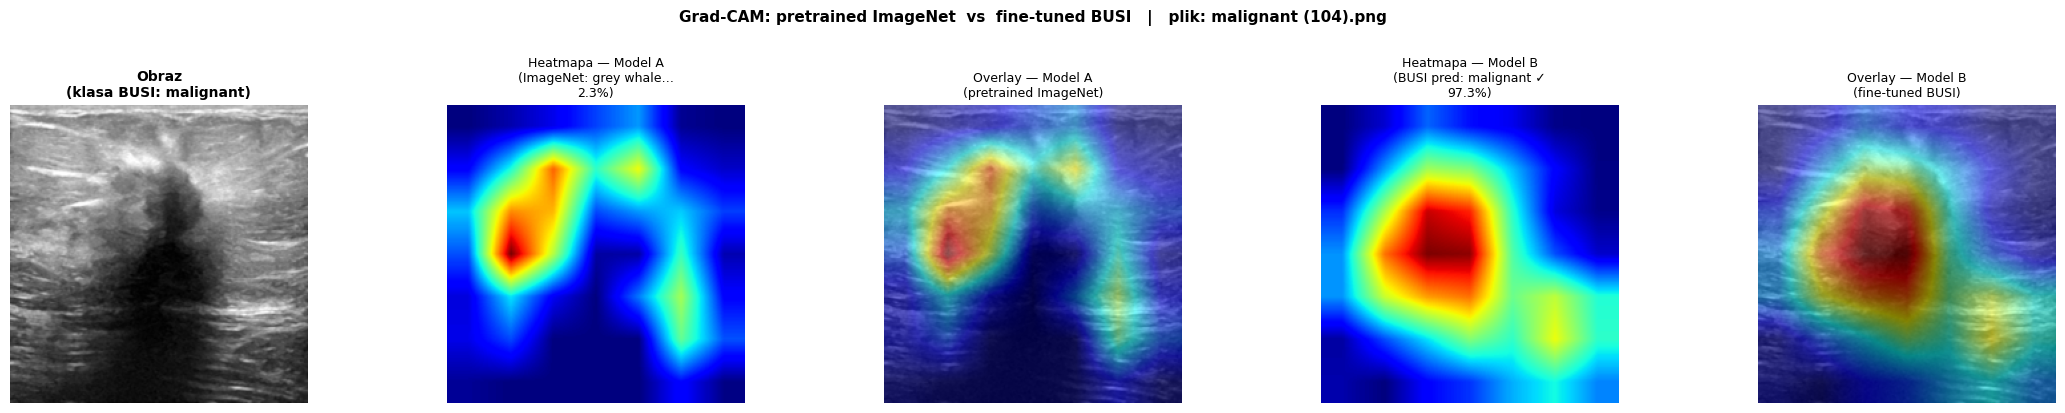


Klasa: NORMAL | Obraz: normal (42).png
  Zapisano: gradcam_outputs/comparison/comparison_normal_normal (42).png


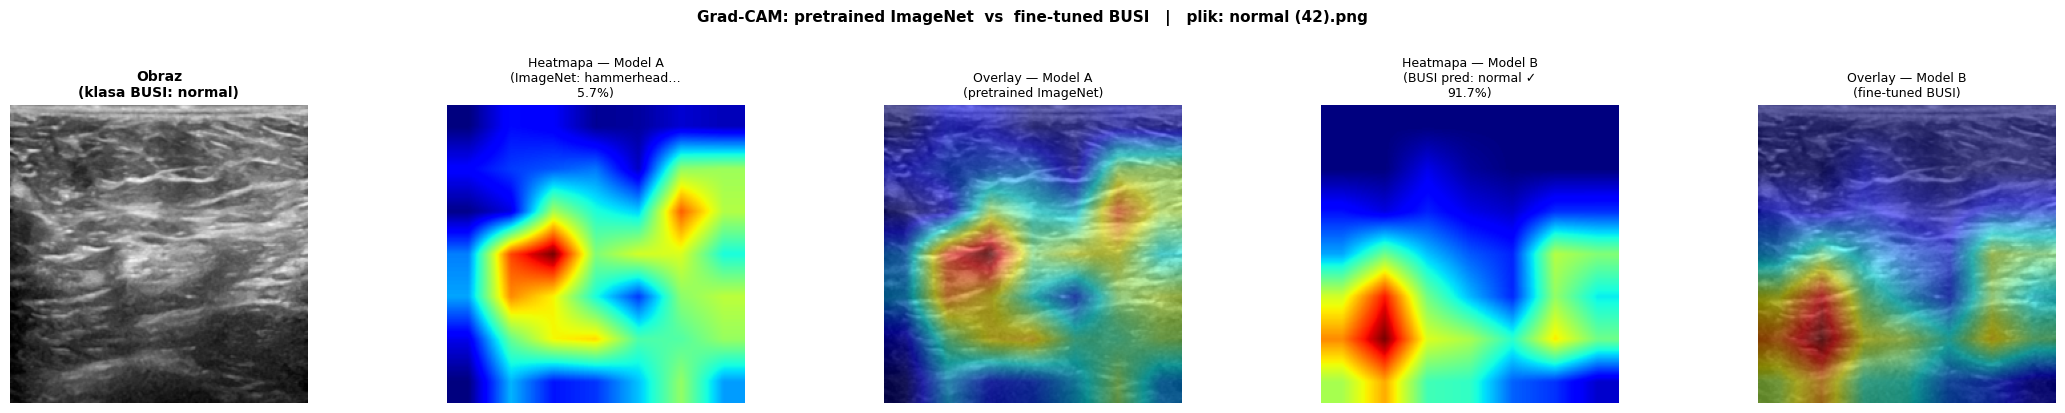


Wszystkie obrazy przetworzone. Wyniki w: gradcam_outputs/comparison/


In [8]:
# Uruchomienie porównania dla jednego obrazu z każdej klasy
summary = []

for cls, img_path in selected.items():
    print(f"\n{'='*60}")
    print(f"Klasa: {cls.upper()} | Obraz: {img_path.name}")
    print('='*60)
    save_path = os.path.join(OUTPUT_DIR, f"comparison_{cls}_{img_path.stem}.png")
    result = compare_gradcam_single(img_path, cls, save_path=save_path)
    summary.append(result)

print(f"\nWszystkie obrazy przetworzone. Wyniki w: {OUTPUT_DIR}/")

## 8. (Opcjonalne) Porównanie dla własnego obrazu

Zmień `CUSTOM_IMAGE_PATH` na ścieżkę do dowolnego obrazu z BUSI.

In [9]:
# Ustaw ścieżkę i klasę ręcznie, jeśli chcesz przetestować konkretny obraz
CUSTOM_IMAGE_PATH = None   # np. 'Dataset_BUSI_with_GT/malignant/malignant (42).png'
CUSTOM_TRUE_CLASS = None   # np. 'malignant'

if CUSTOM_IMAGE_PATH and CUSTOM_TRUE_CLASS:
    compare_gradcam_single(
        CUSTOM_IMAGE_PATH,
        CUSTOM_TRUE_CLASS,
        save_path=os.path.join(OUTPUT_DIR, 'comparison_custom.png')
    )
else:
    print("Nie ustawiono własnego obrazu. Zmień CUSTOM_IMAGE_PATH i CUSTOM_TRUE_CLASS powyżej.")

Nie ustawiono własnego obrazu. Zmień CUSTOM_IMAGE_PATH i CUSTOM_TRUE_CLASS powyżej.


## 9. Podsumowanie wyników

In [10]:
import pandas as pd

df = pd.DataFrame(summary)
df['model_B_correct'] = df['model_B_correct'].map({True: '✓', False: '✗'})
df.columns = ['Obraz', 'Prawdziwa klasa',
               'Model A — pred (ImageNet)', 'Model A — prob',
               'Model B — pred (BUSI)',    'Model B — prob',
               'Model B — poprawna?']

print("Podsumowanie predykcji:")
print(df.to_string(index=False))

print(f"\nWizualizacje zapisane w: {OUTPUT_DIR}/")
saved_files = sorted(Path(OUTPUT_DIR).glob('*.png'))
for f in saved_files:
    print(f"  {f.name}")

Podsumowanie predykcji:
              Obraz Prawdziwa klasa Model A — pred (ImageNet)  Model A — prob Model B — pred (BUSI)  Model B — prob Model B — poprawna?
   benign (124).png          benign                hammerhead        0.048285                benign        0.533640                   ✓
malignant (104).png       malignant                grey whale        0.022584             malignant        0.972521                   ✓
    normal (42).png          normal                hammerhead        0.056884                normal        0.916952                   ✓

Wizualizacje zapisane w: gradcam_outputs/comparison/
  comparison_benign_benign (124).png
  comparison_malignant_malignant (104).png
  comparison_normal_normal (42).png


## Wnioski

### Co widać na mapach Grad-CAM?

**Model A (pretrained ImageNet, ResNet50)**
- Wagi nauczyły się rozpoznawać ogólne cechy wizualne (tekstury, krawędzie, kształty z naturalnych zdjęć).
- Na obrazach ultrasonograficznych BUSI model skupia uwagę losowo lub na artefaktach tła — **nie „wie" czym jest zmiana nowotworowa**.
- Predykcja to losowa etykieta ImageNet niezwiązana z medycyną.

**Model B (fine-tuned BUSI, ResNet18)**
- Backbone używa tych samych wag ImageNet, ale ostatnia warstwa klasyfikacyjna nauczyła się mapować cechy backbone'u na 3 klasy BUSI.
- Grad-CAM powinien pokazywać większe skupienie na **obszarach zmiany** w obrazie ultrasonograficznym, ponieważ model był nagradzany za ich poprawną klasyfikację.
- Nawet bez trenowania backbone'u reprezentacje ImageNet są wystarczająco bogate, by fine-tuning FC dał rozsądne wyniki.

### Kluczowa obserwacja
> Ten sam backbone → zupełnie inne punkty skupienia uwagi, gdy zmieniliśmy cel klasyfikacji.
> Grad-CAM ujawnia różnicę w „intencji" modelu, chociaż architektura sieci jest prawie taka sama.